In [87]:
# Import Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.utils import to_categorical
import matplotlib.pyplot as plt

In [88]:
# Load drive
from google.colab import drive
drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [89]:
# Data Paths
expr_data_2c = '/content/drive/MyDrive/stress_classification/TheFacialExpressions/facial_dataset_2_class.csv'

#### Data Processing

In [90]:
# Load data
data = pd.read_csv(expr_data_2c)
print(data[:10])

   emotion                                             pixels     Usage
0        0  77 78 79 79 78 75 60 55 47 48 58 73 77 79 57 5...  Training
1        0  85 84 90 121 101 102 133 153 153 169 177 189 1...  Training
2        0  4 2 13 41 56 62 67 87 95 62 65 70 80 107 127 1...  Training
3        0  107 107 109 109 109 109 110 101 123 140 144 14...  Training
4        0  14 14 18 28 27 22 21 30 42 61 77 86 88 95 100 ...  Training
5        0  252 250 246 229 182 140 98 72 53 44 67 95 95 8...  Training
6        0  224 227 219 217 215 210 187 177 189 200 206 21...  Training
7        0  162 200 187 180 197 198 196 192 176 152 136 11...  Training
8        0  210 210 210 210 211 207 147 103 68 60 47 70 12...  Training
9        0  50 44 74 141 187 187 169 113 80 128 181 172 76...  Training


In [91]:
# Extract pixel data and convert it to numpy array
pixel_data = data['pixels'].apply(lambda x: np.array(x.split(), dtype="float32"))
pixels = np.vstack(pixel_data.values)
pixels = pixels.reshape(-1, 48, 48, 1)  # assuming grayscale images

# Extract emotion labels
emotions = data['emotion'].values

# Classes
total_classes = len(np.unique(emotions))
print("Classes: " + str(np.unique(emotions)) + "total_classes: " + str(total_classes))

Classes: [0 1]total_classes: 2


In [92]:
# Preprocess the data
pixels /= 255.0  # normalize pixel values between 0 and 1
le = LabelEncoder()
emotions = le.fit_transform(emotions)
emotions = to_categorical(emotions)

# Split the data into training, validation and testing sets
x_train_temp, x_test, y_train_temp, y_test = train_test_split(pixels, emotions, test_size=0.1, random_state=42)
x_train, x_valid, y_train, y_valid = train_test_split(x_train_temp, y_train_temp, test_size=0.2, random_state=42)

print("Normalized Data (pixels): " + str(pixels[1]))
print("\nTraining data: " + str(len(x_train)))
print("Validation data: " + str(len(x_valid)))
print("Test data: " + str(len(x_test)))

# # Classes
# total_classes = len(np.unique(emotions))
# print("Classes: " + str(np.unique(emotions)) + "total_classes: " + str(total_classes))

Normalized Data (pixels): [[[0.33333334]
  [0.32941177]
  [0.3529412 ]
  ...
  [0.15686275]
  [0.18039216]
  [0.24705882]]

 [[0.30588236]
  [0.29803923]
  [0.39607844]
  ...
  [0.14117648]
  [0.17254902]
  [0.20392157]]

 [[0.29803923]
  [0.3764706 ]
  [0.4509804 ]
  ...
  [0.13333334]
  [0.16470589]
  [0.16862746]]

 ...

 [[0.4       ]
  [0.39215687]
  [0.38039216]
  ...
  [0.25490198]
  [0.29803923]
  [0.24313726]]

 [[0.41960785]
  [0.39607844]
  [0.3764706 ]
  ...
  [0.22352941]
  [0.30980393]
  [0.27450982]]

 [[0.41568628]
  [0.40392157]
  [0.36862746]
  ...
  [0.22745098]
  [0.28627452]
  [0.32941177]]]

Training data: 21974
Validation data: 5494
Test data: 3052


#### Model Implementation

In [93]:
# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(48, 48, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(total_classes, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 46, 46, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 23, 23, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 21, 21, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 10, 10, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 6400)              0         
                                                                 
 dense_12 (Dense)            (None, 128)              

In [81]:
# VGG16
import keras
from keras.applications import EfficientNetB0, ResNet50, MobileNetV2, VGG16
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D

# Convert pixel data to 3 channels (VGG16 expects 3 channels)
x_train = np.stack([x_train[:, :, :, 0]] * 3, axis=-1)
x_valid = np.stack([x_valid[:, :, :, 0]] * 3, axis=-1)
x_test = np.stack([x_test[:, :, :, 0]] * 3, axis=-1)

# Load the EfficientNetB0 model (include_top=False to exclude the fully connected layers)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(48, 48, 3))

# Build your model on top of EfficientNetB0
model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu'))
model.add(Dense(total_classes, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 1, 1, 512)         14714688  
                                                                 
 global_average_pooling2d_5  (None, 512)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_10 (Dense)            (None, 128)               65664     
                                                                 
 dense_11 (Dense)            (None, 2)                 258       
                                                                 
Total params: 14780610 (56.38 MB)
Trainable params: 14780610 (56.38 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [94]:
# model_path = '/content/drive/MyDrive/stress_classification/models_fexprsn/checkpoint.weights.vgg16.7c.h5'
# checkpoint = keras.callbacks.ModelCheckpoint(
#     model_path,
#     save_weights_only=True,
#     monitor='val_loss',
#     mode='min',
#     save_best_only=True
# )
history = model.fit(x_train, y_train, validation_data=(x_valid, y_valid), epochs=10, batch_size=128)

Epoch 1/10
172/172 [==============================] - 5s 19ms/step - loss: 0.6418 - accuracy: 0.6274 - val_loss: 0.6200 - val_accuracy: 0.6545
Epoch 2/10
172/172 [==============================] - 2s 13ms/step - loss: 0.5475 - accuracy: 0.7237 - val_loss: 0.5303 - val_accuracy: 0.7262
Epoch 3/10
172/172 [==============================] - 3s 16ms/step - loss: 0.4881 - accuracy: 0.7637 - val_loss: 0.4872 - val_accuracy: 0.7616
Epoch 4/10
172/172 [==============================] - 2s 12ms/step - loss: 0.4559 - accuracy: 0.7842 - val_loss: 0.4631 - val_accuracy: 0.7819
Epoch 5/10
172/172 [==============================] - 2s 10ms/step - loss: 0.4241 - accuracy: 0.8051 - val_loss: 0.4613 - val_accuracy: 0.7892
Epoch 6/10
172/172 [==============================] - 2s 13ms/step - loss: 0.3987 - accuracy: 0.8190 - val_loss: 0.4501 - val_accuracy: 0.7940
Epoch 7/10
172/172 [==============================] - 2s 11ms/step - loss: 0.3769 - accuracy: 0.8297 - val_loss: 0.4390 - val_accuracy: 0.7974

In [95]:
model.save('/content/drive/MyDrive/stress_classification/models_fexprsn/cnn_2c.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [96]:
def plot_acc_loss(history):
  # Plot training and validation accuracy
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

  # Plot training and validation loss
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

In [97]:
def evaluate_model(model,x_test,y_test):
  # Predict on the test set
  y_pred = model.predict(x_test)
  y_pred = np.argmax(y_pred, axis=1)
  y_test = np.argmax(y_test, axis=1)

  # Confusion matrix
  conf_matrix = confusion_matrix(y_test, y_pred)
  plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
  plt.title('Confusion Matrix')
  plt.colorbar()
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.show()

  # Classification report
  class_report = classification_report(y_test, y_pred)
  print("\nClassification Report:")
  print(class_report)

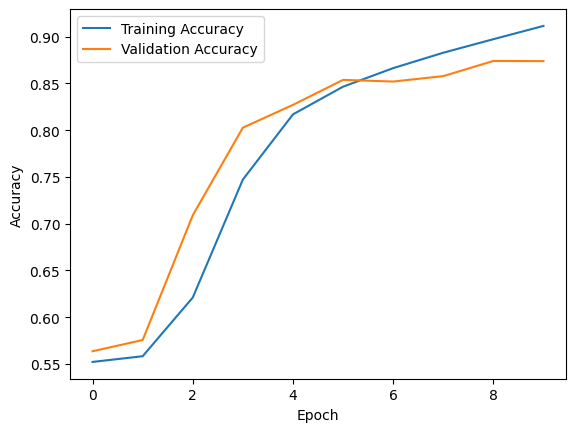

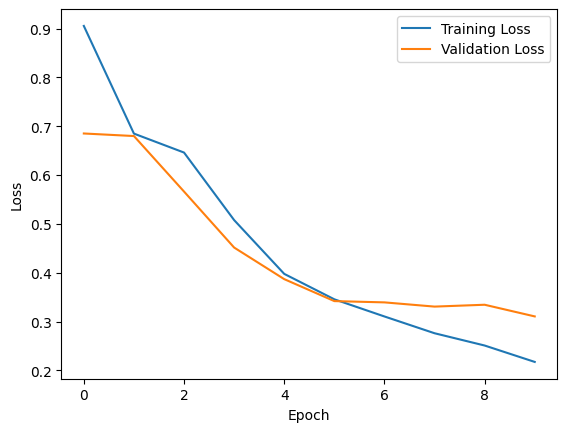

96/96 [==============================] - 3s 16ms/step


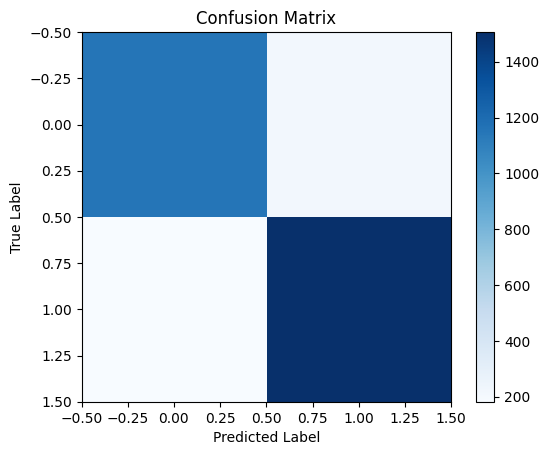


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1364
           1       0.88      0.89      0.88      1688

    accuracy                           0.87      3052
   macro avg       0.87      0.87      0.87      3052
weighted avg       0.87      0.87      0.87      3052



In [24]:
# VGG16 - 2 classes
plot_acc_loss(history)
evaluate_model(model,x_test,y_test)

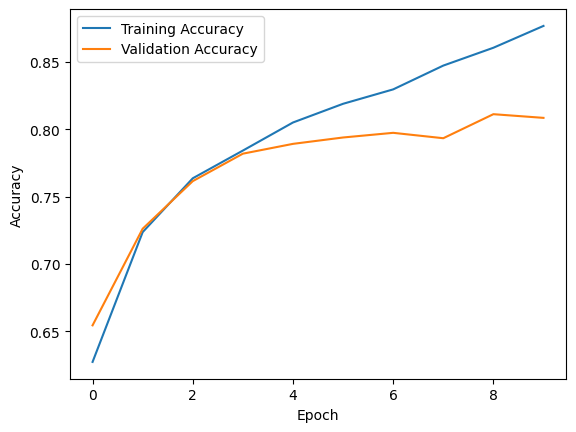

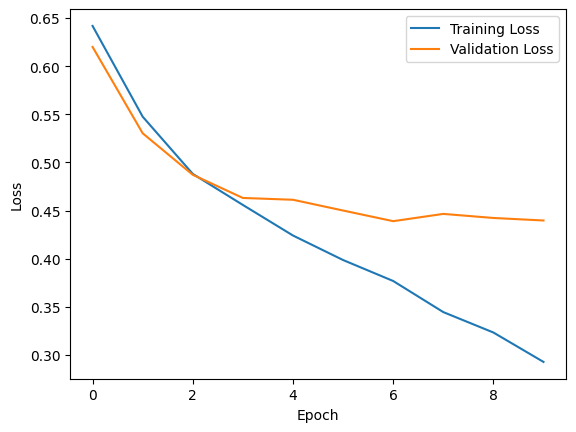

96/96 [==============================] - 1s 4ms/step


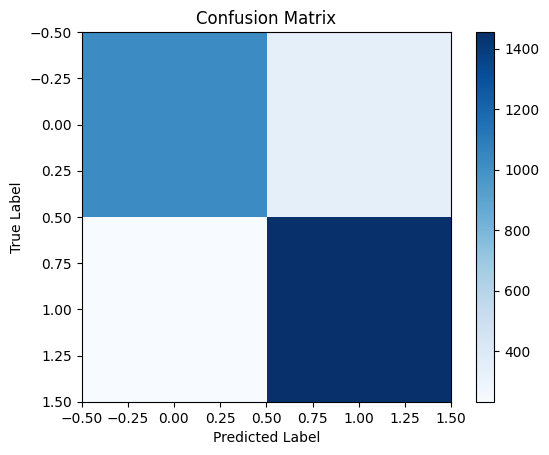


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78      1364
           1       0.81      0.86      0.84      1688

    accuracy                           0.81      3052
   macro avg       0.81      0.81      0.81      3052
weighted avg       0.81      0.81      0.81      3052



In [99]:
# CNN - 2 classes
plot_acc_loss(history)
evaluate_model(model,x_test,y_test)